# Frequency scan of the final pulse in a truncated LMT sequence

This notebook reuses the same lab pulse sequence as `true_LMT_trajectory.ipynb`,
truncates it to the first `N` pulses, and then scans the laser frequency
(detuning) of the **final, Nth pulse** over +/- 10 recoil frequencies.

For each detuning we run the full Borde-frame simulation for an *ideal atom* --
one with no extra velocity (the centre of the velocity distribution, i.e.
exactly the `INITIAL_VELOCITY_Z` the sequence was designed for) and at the
centre of the cloud (`position = 0`).

**Frame note (gravity / Doppler).** `build_sequence_from_lab_pulse_dump`
already removes the full Doppler shift `v(t)/lambda` of the central falling
atom -- both the constant `v0` part *and* the gravity ramp `g*t` -- with the
opposite sign on the up vs down beam, transforming the lab pulse train into the
central atom's rest frame. It also assumes the first pulse is on resonance
there. So the ideal atom must be simulated at **`vz = 0`** in that frame:
passing `v0` again would double-count the constant Doppler and shift the
resonance by `+/- v0/lambda ~ +/- 0.5` recoil, oppositely for the up vs down
beam. (The gravity ramp is what keeps the resonance time-independent; flipping
its sign would move late pulses by tens of recoils.)

Each plot shows two traces: one where the final pulse is delivered on the **up**
beam (`k = +1`) and one where it is on the **down** beam (`k = -1`). We repeat
the plot for `N = 1, 2, 3, 4, 5`.

In [1]:
import sys
import dataclasses

sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq

## Lab pulse dump

Same dump and `INITIAL_VELOCITY_Z` as `true_LMT_trajectory.ipynb`.

In [2]:
pulse_sequence = [[[1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0], [4936, 2691191, 2771190, 2838189, 2918188, 2985187, 3065186, 3132185, 3212184, 3279183, 3359182, 3426181, 3506180, 3573179, 3653178, 3720177, 3800176, 4077207, 4122991, 4286111, 4392695, 4722709, 4809244, 4922367, 5030207, 5108734, 5221855, 5328439, 5508438, 5594973, 5908111, 6019623], [380000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 34000, 99999, 99999, 68000, 68000, 99999, 99999, 68000, 99999, 99999, 68000, 68000, 99999, 99999, 34000], [80000000, 79971814, 80020109, 79988550, 80003372, 80005286, 79986636, 80022022, 79969900, 80038758, 79953164, 80055494, 79936428, 80072230, 79919692, 80088966, 79902956, 80027353, 79983322, 79966812, 80004123, 79999490, 79974157, 79994546, 80013772, 79978362, 79998751, 80028585, 80026058, 80003989, 79989586, 80000149], [200000000, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200000500, 200005800, 200005800, 200000500, 200000500, 200005800, 200000500, 200000500, 200005800, 200005800, 200000500, 200000500, 200005800], [99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]]

(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    switch_hz,
    delivery_hz,
    delivery_setpoint,
) = pulse_sequence[0]

is_up = np.array(is_up)
start_times_mu = np.array(start_times_mu)
durations_mu = np.array(durations_mu)
opll_hz = np.array(opll_hz)
switch_hz = np.array(switch_hz)
delivery_hz = np.array(delivery_hz)
delivery_setpoint = np.array(delivery_setpoint)

# --- HACKY AUTO-CALIBRATION (a warning is emitted at runtime) ---
# alpha (probe-shift coefficient) and v0 (initial atom velocity) used to be
# hand-tuned magic numbers. Instead we now back them out of the lab pulse dump:
# alpha from how the up-beam pulses sit relative to each other vs their Rabi
# frequency, and v0 from the residual up/down detuning once alpha is applied.
# This is a self-consistent fit, NOT a measurement -- replace with real
# light-shift and launch-velocity calibrations.
PROBE_SHIFT_ALPHA, INITIAL_VELOCITY_Z = (
    seq.calibrate_probe_shift_and_velocity_from_dump(
        is_up=is_up,
        start_times_mu=start_times_mu,
        durations_mu=durations_mu,
        opll_hz=opll_hz,
        switch_hz=switch_hz,
        delivery_hz=delivery_hz,
        delivery_setpoint=delivery_setpoint,
    )
)
print(f"auto-calibrated probe-shift alpha = {PROBE_SHIFT_ALPHA:.4e} /Hz")
print(f"auto-calibrated initial velocity  = {INITIAL_VELOCITY_Z:.4e} m/s")

In [3]:
sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=INITIAL_VELOCITY_Z,
    probe_induced_alpha_up=PROBE_SHIFT_ALPHA,
    probe_induced_alpha_down=PROBE_SHIFT_ALPHA,
)

# Skip the first freefall, exactly as in true_LMT_trajectory.ipynb, so the
# sequence starts on the first pulse.
sequence = sequence[1:]

print(f'{len(sequence)} events, '
      f'{sum(isinstance(e, seq.Pulse) for e in sequence)} pulses')

63 events, 32 pulses


## Truncate and scan helpers

`truncate_to_n_pulses` keeps every event up to and including the Nth pulse (so
any trailing freefall after the Nth pulse is dropped -- it does not change the
excitation fraction). `scan_final_pulse` then sweeps the final pulse's detuning
for a chosen beam direction `k`.

In [4]:
def truncate_to_n_pulses(events, n):
    """Return the prefix of `events` ending on the nth Pulse (1-indexed)."""
    out = []
    n_pulses = 0
    for event in events:
        out.append(event)
        if isinstance(event, seq.Pulse):
            n_pulses += 1
            if n_pulses == n:
                return out
    raise ValueError(
        f'Sequence only contains {n_pulses} pulses, cannot truncate to {n}'
    )


def first_pulse_detuning(events):
    """Detuning (Hz) of the first pulse -- the 'convention zero' resonance."""
    for event in events:
        if isinstance(event, seq.Pulse):
            return event.detuning_hz
    raise ValueError('Sequence contains no pulses')


def scan_final_pulse(events, n, k, offsets_recoils, reference_detuning_hz):
    """Excitation fraction vs the final pulse's ABSOLUTE detuning.

    The final pulse's detuning is set to ``reference_detuning_hz + offset*RF``
    for each offset, with its beam direction forced to `k`. Referencing every
    scan to the same ``reference_detuning_hz`` (the first pulse's resonance)
    means a given atomic transition lands at the same x for all N -- so a
    same-beam pulse driving the same transition as pulse 1 shows up at offset 0.

    The ideal atom is simulated at vz = 0 (the builder already removed the full
    Doppler of the central falling atom; see the frame note above).
    """
    truncated = truncate_to_n_pulses(events, n)
    excitation_fraction = np.empty(len(offsets_recoils))
    for i, offset in enumerate(offsets_recoils):
        detuning_hz = reference_detuning_hz + offset * sim.RECOIL_FREQUENCY_HZ
        scanned = list(truncated)
        scanned[-1] = dataclasses.replace(
            scanned[-1], k=k, detuning_hz=detuning_hz
        )
        excitation_fraction[i] = (
            seq.calculate_excited_fraction_for_pulse_sequence(
                scanned,
                velocity=(0.0, 0.0, 0.0),
                position=(0.0, 0.0, 0.0),
            )
        )
    return excitation_fraction

## Scan the final-pulse detuning for N = 1..5 -- beam x OPLL variants

We sweep the final pulse over +/- 10 recoil frequencies and overlay the up-beam
(`k = +1`) and down-beam (`k = -1`) traces. We do this for a 2x2 set of
sequences defined by two build-time knobs:

| variant | beams (`is_up`) | OPLL |
|---------|-----------------|------|
| 1 | up/down as recorded | normal |
| 2 | flipped (down/up)   | normal |
| 3 | up/down as recorded | inverted (`opll_hz * -1`) |
| 4 | flipped (down/up)   | inverted (`opll_hz * -1`) |

- **Beam flip** inverts `is_up`, so every pulse swaps up <-> down.
- **OPLL invert** multiplies `opll_hz` by -1. Because the builder anchors the
  detuning scale on the first pulse (it assumes pulse 1 is on resonance),
  inverting the OPLL re-centres everything: pulse 1 stays the convention zero
  and the remaining pulses move relative to it.

Both knobs are applied at build time via `build_variant(beam_is_up, opll)`, and
every build is then probe-corrected with `correct_probe_shift` (exact; leaves the
excitation curves unchanged, just puts detunings on the bare recoil ladder).

**Common frequency axis.** The x-axis is the final pulse's detuning *relative to
the first pulse's resonance* (the convention zero), the same reference for every
N. So a same-beam pulse that drives pulse 1's transition shows up at offset 0.

**Markers on each panel.** The dashed grey line at offset 0 is the first-pulse
resonance. The thick dotted vertical line marks the detuning at which the
*actual* Nth pulse was performed in that variant's sequence, **coloured by the
beam it actually used** (blue = up, red = down). The ideal atom is at `vz = 0`
throughout.

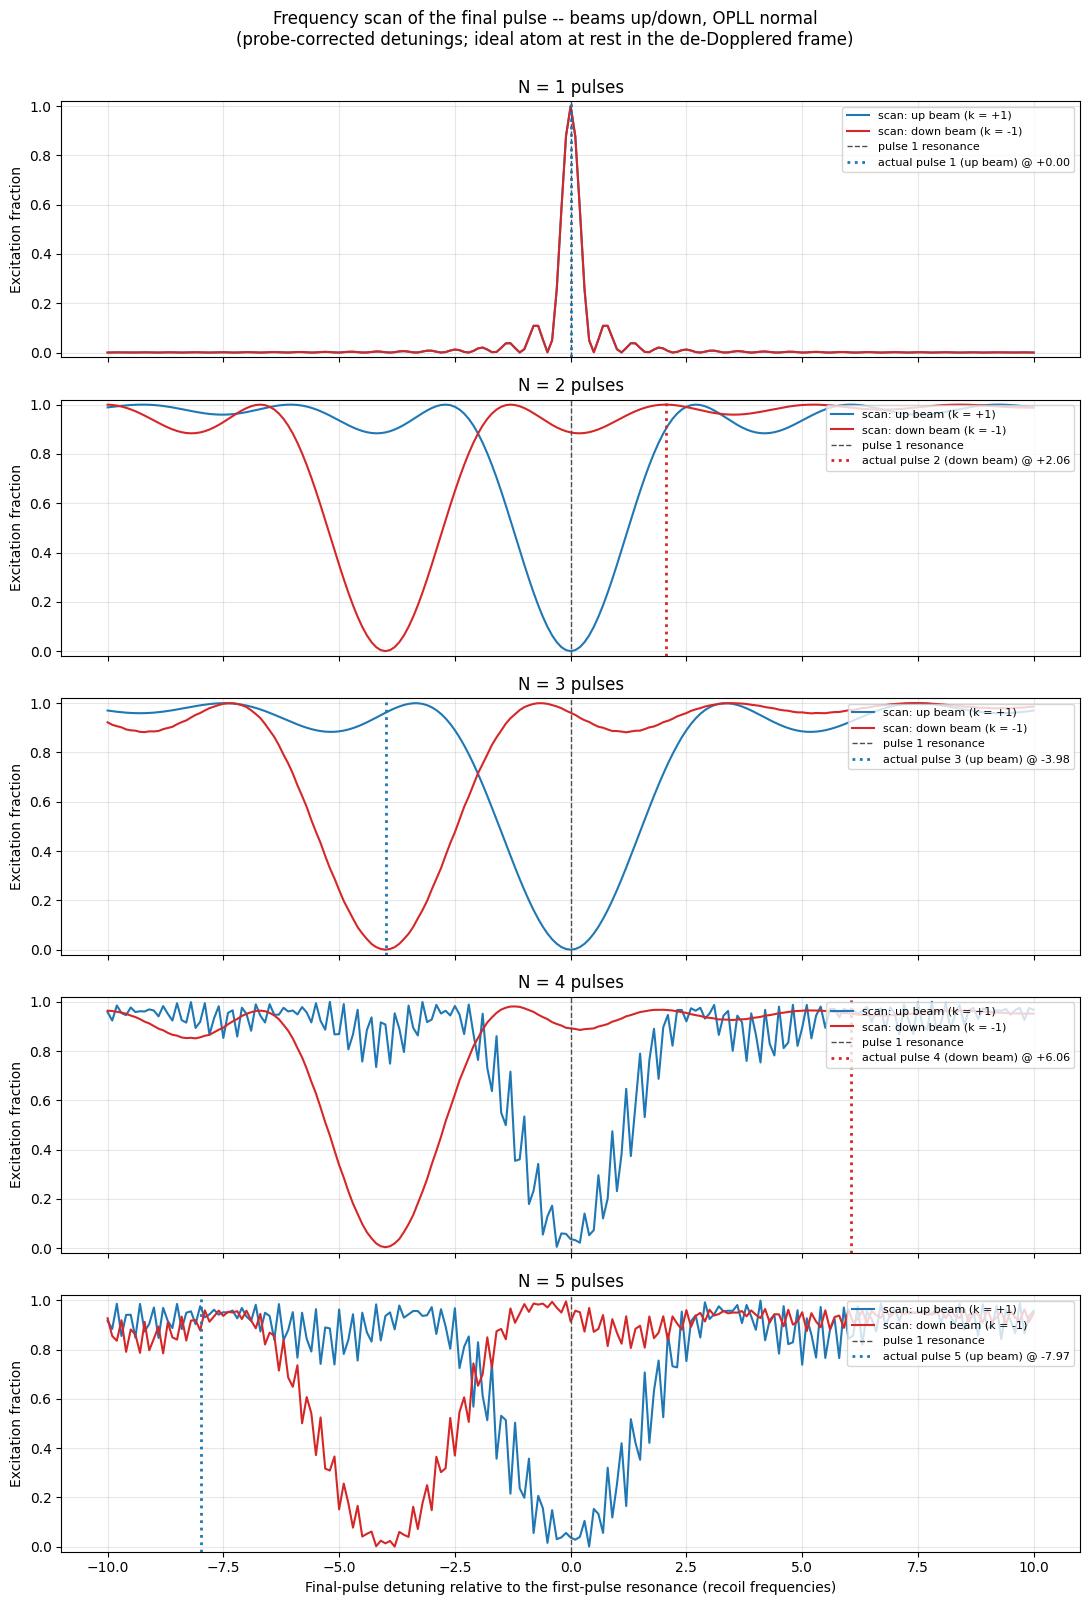

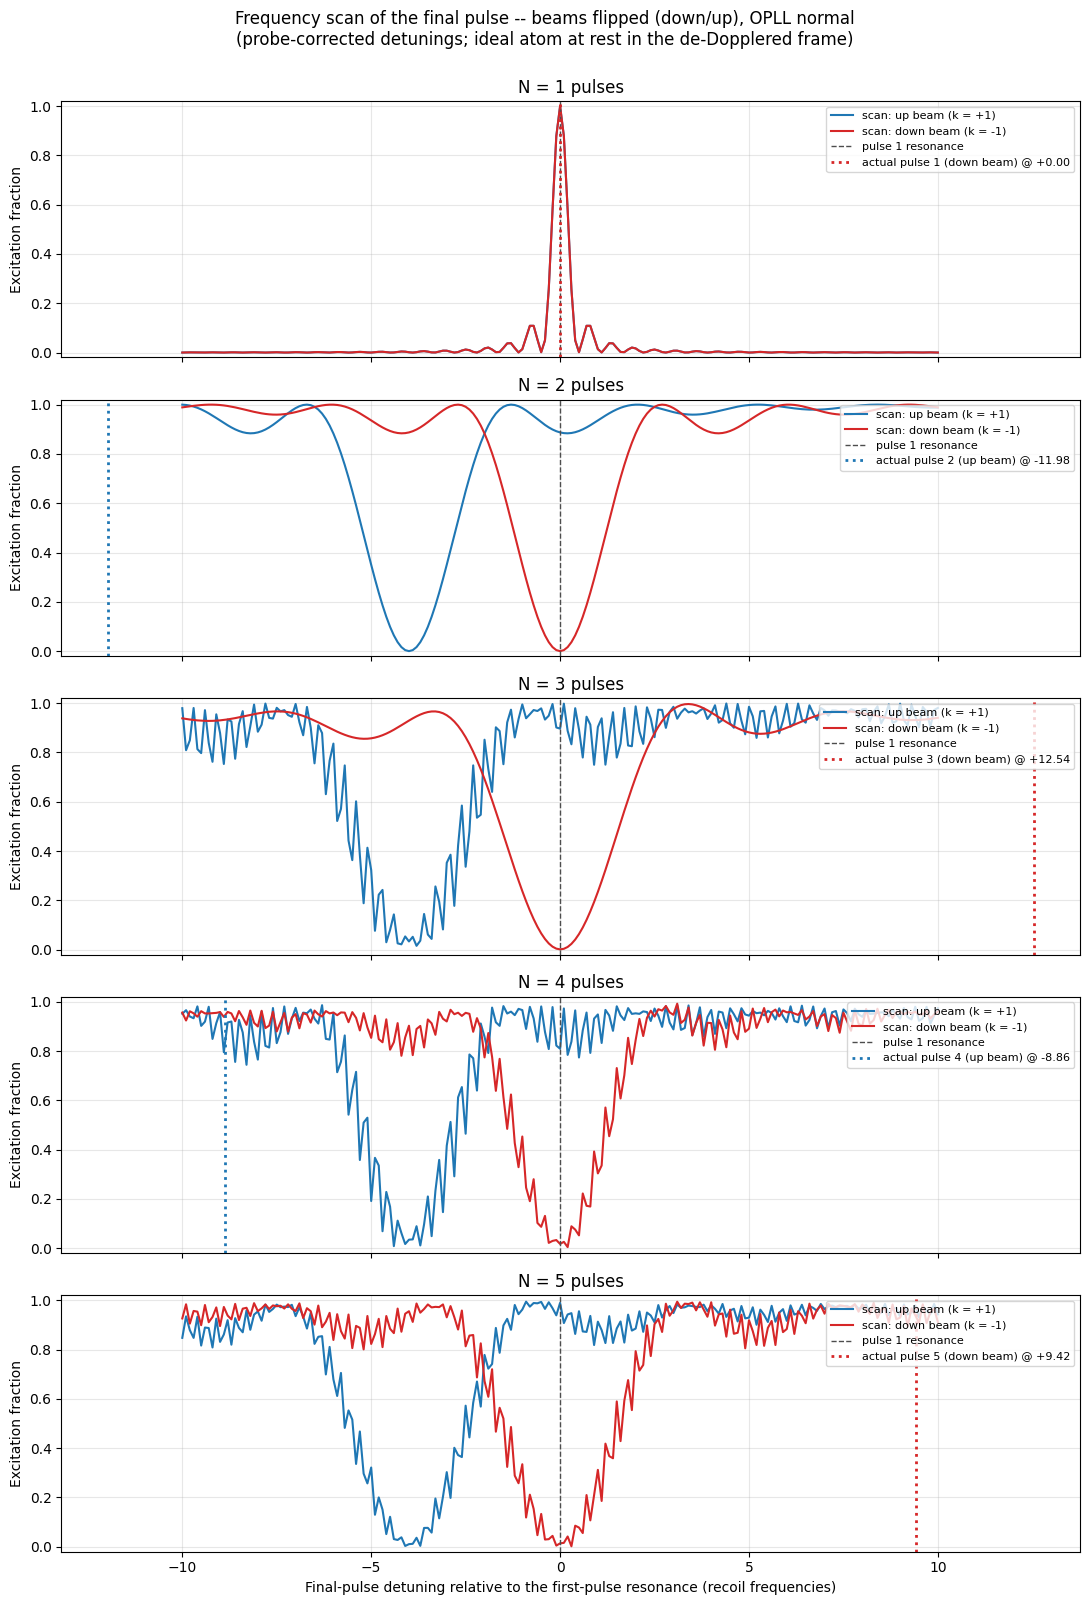

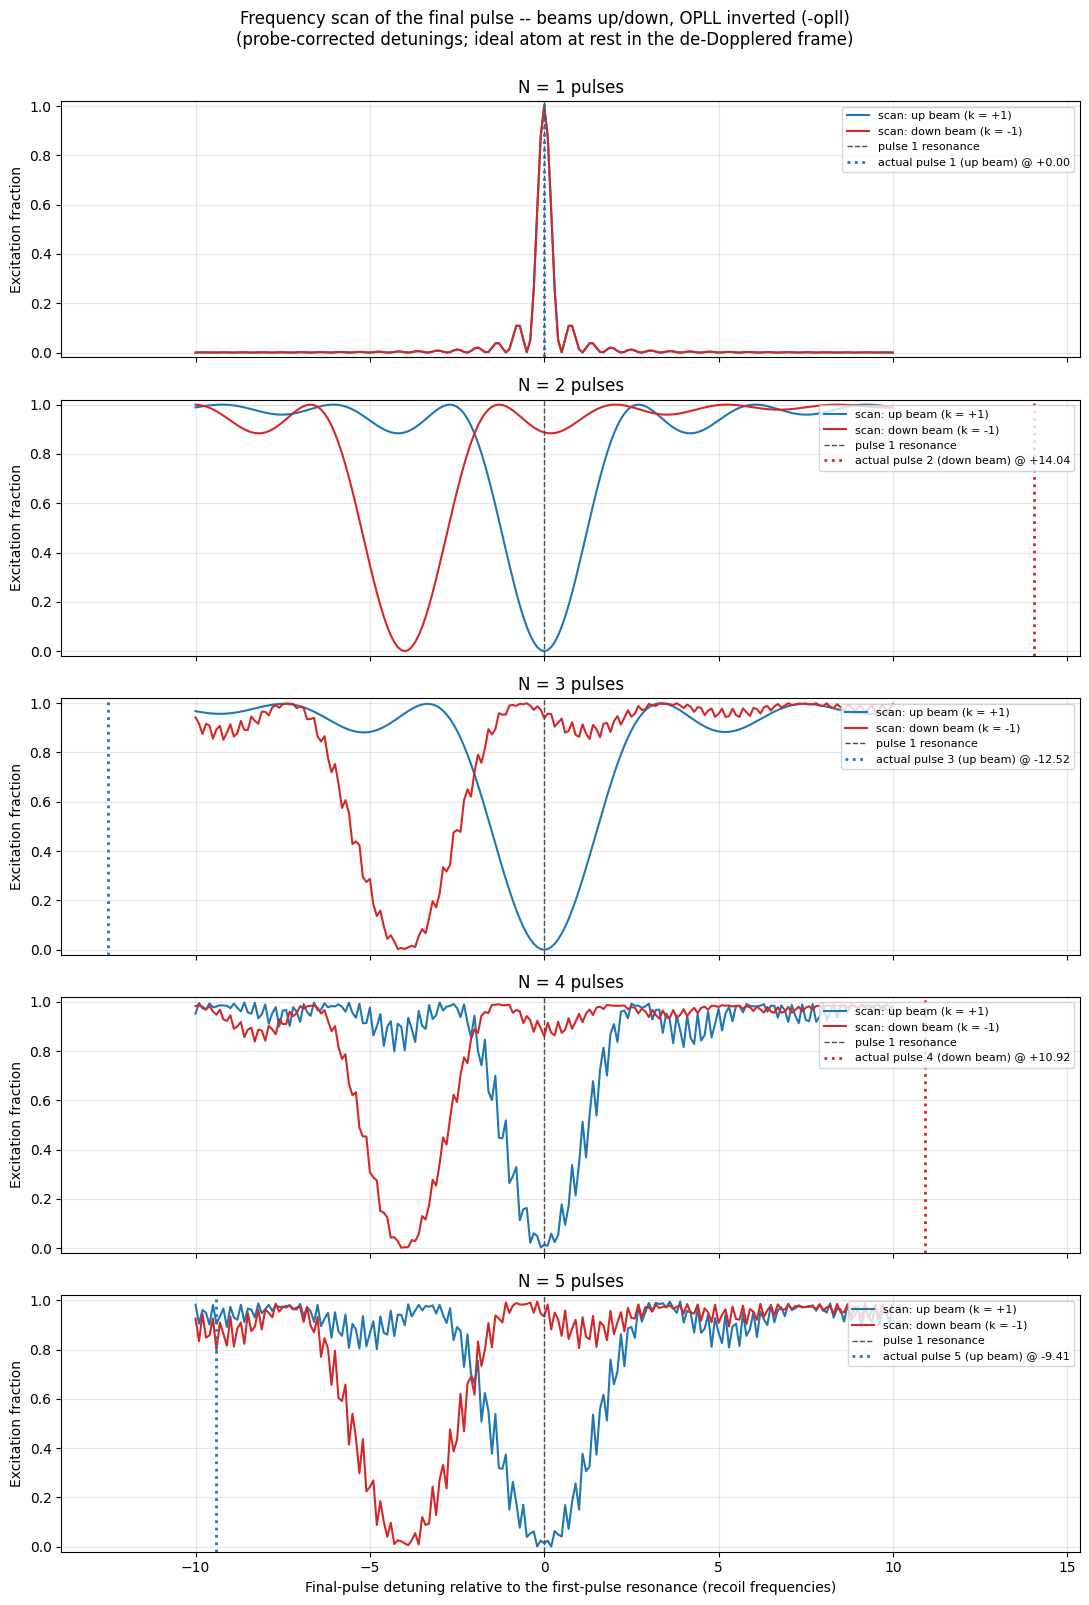

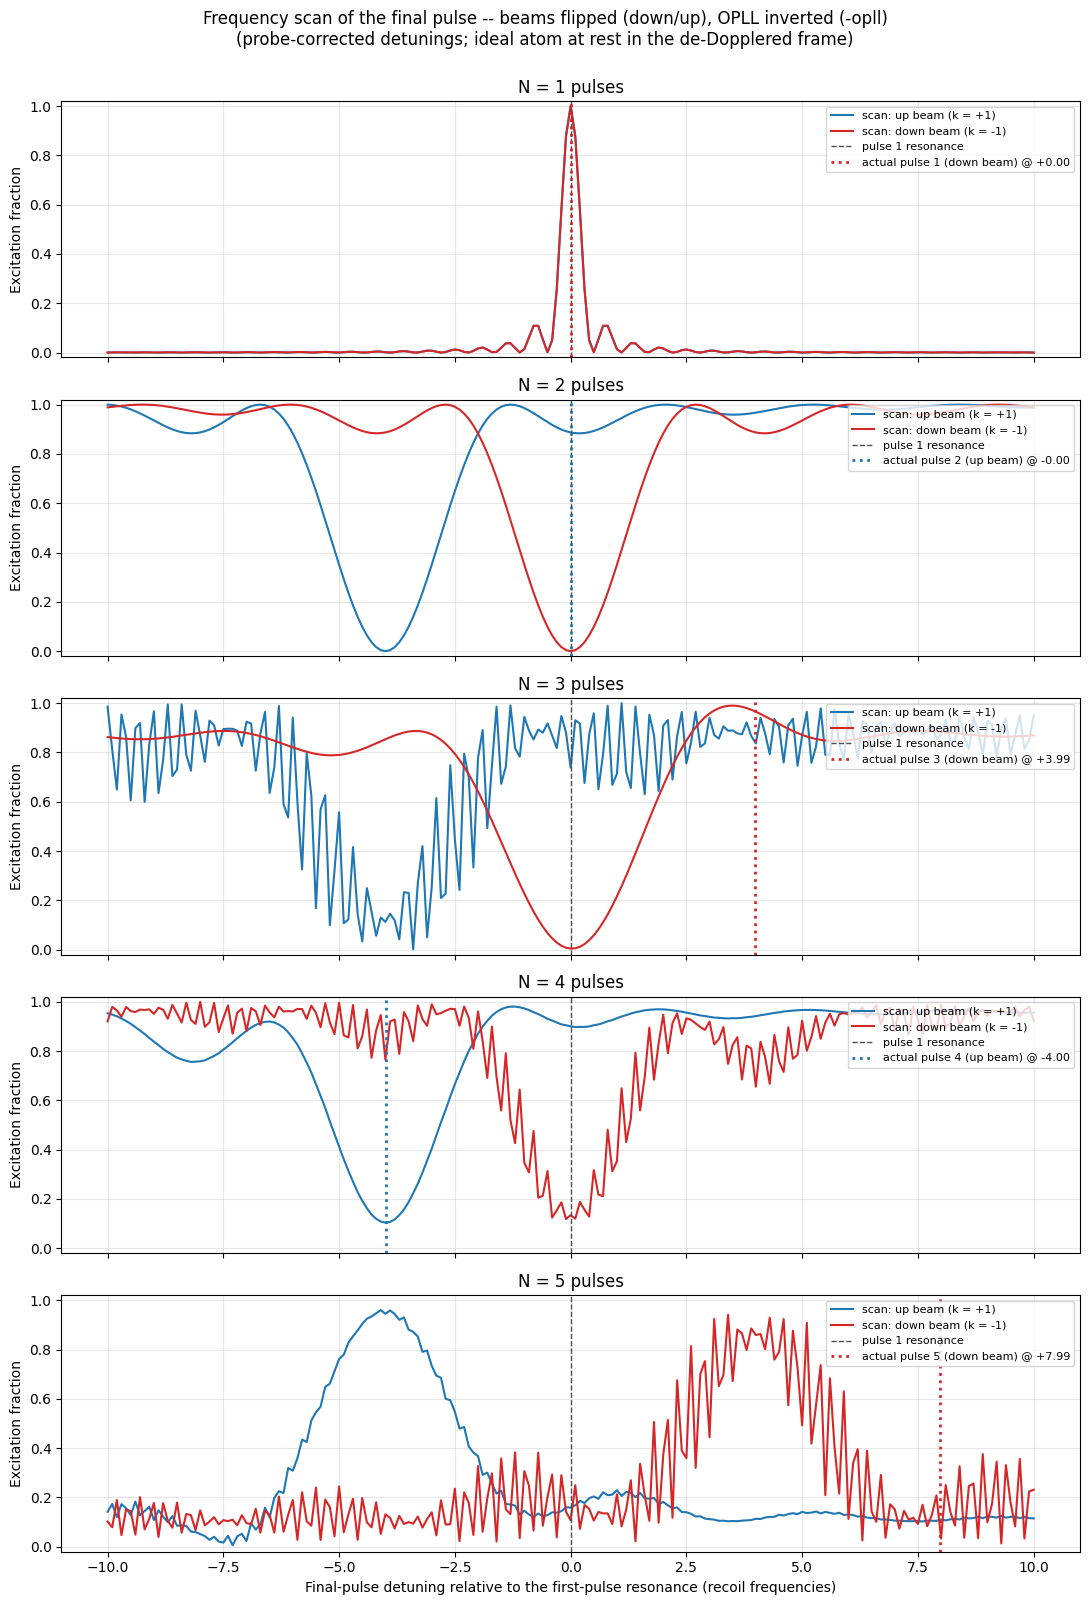

In [5]:
scan_halfwidth_recoils = 10.0
n_points = 201
N_values = [1, 2, 3, 4, 5]

offsets_recoils = np.linspace(
    -scan_halfwidth_recoils, scan_halfwidth_recoils, n_points
)


def correct_probe_shift(events):
    """Fold each pulse's probe-induced (AC-Stark) shift into its detuning.

    The simulation uses an effective detuning of
    ``detuning_hz - probe_shift_coefficient * rabi_frequency**2`` during a pulse.
    Here we bake that shift straight into ``detuning_hz`` and zero the
    coefficient, so the stored detunings ARE the effective (bare recoil-ladder)
    detunings. This is exact -- it leaves the simulated excitation unchanged --
    but the design detunings now sit on the clean recoil ladder.
    """
    out = []
    for event in events:
        if isinstance(event, seq.Pulse):
            shift = event.probe_shift_coefficient * event.rabi_frequency**2
            out.append(dataclasses.replace(
                event,
                detuning_hz=event.detuning_hz - shift,
                probe_shift_coefficient=0.0,
            ))
        else:
            out.append(event)
    return out


# Both knobs act at BUILD time (they are inputs to the lab-dump builder):
#   * beam flip  : invert is_up, so up<->down on every pulse
#   * OPLL invert: multiply opll_hz by -1
# In both cases the builder re-anchors on the first pulse (it assumes pulse 1 is
# on resonance), so pulse 1 stays the convention-zero reference and everything
# else moves relative to it.
is_up_bool = is_up.astype(bool)


def build_variant(beam_is_up, opll):
    seqn = seq.build_sequence_from_lab_pulse_dump(
        is_up=beam_is_up,
        start_times_mu=start_times_mu,
        durations_mu=durations_mu,
        opll_hz=opll,
        switch_hz=switch_hz,
        delivery_hz=delivery_hz,
        delivery_setpoint=delivery_setpoint,
        initial_velocity_z=INITIAL_VELOCITY_Z,
        probe_induced_alpha_up=PROBE_SHIFT_ALPHA,
        probe_induced_alpha_down=PROBE_SHIFT_ALPHA,
    )[1:]
    return correct_probe_shift(seqn)


variants = [
    ('beams up/down, OPLL normal',
     build_variant(is_up_bool, opll_hz)),
    ('beams flipped (down/up), OPLL normal',
     build_variant(np.logical_not(is_up_bool), opll_hz)),
    ('beams up/down, OPLL inverted (-opll)',
     build_variant(is_up_bool, -opll_hz)),
    ('beams flipped (down/up), OPLL inverted (-opll)',
     build_variant(np.logical_not(is_up_bool), -opll_hz)),
]

BEAM_COLOR = {+1: 'tab:blue', -1: 'tab:red'}
BEAM_NAME = {+1: 'up', -1: 'down'}


def plot_final_pulse_scan(events, suptitle):
    # Common x reference for every panel: the first pulse's resonance. A given
    # atomic transition then lands at the same x for all N, so a same-beam pulse
    # driving pulse 1's transition appears at offset 0.
    reference_detuning_hz = first_pulse_detuning(events)

    fig, axes = plt.subplots(
        len(N_values), 1, figsize=(11, 3.2 * len(N_values)), sharex=True
    )
    for ax, N in zip(axes, N_values):
        exc_up = scan_final_pulse(
            events, N, +1, offsets_recoils, reference_detuning_hz)
        exc_down = scan_final_pulse(
            events, N, -1, offsets_recoils, reference_detuning_hz)

        ax.plot(offsets_recoils, exc_up,
                color='tab:blue', label='scan: up beam (k = +1)')
        ax.plot(offsets_recoils, exc_down,
                color='tab:red', label='scan: down beam (k = -1)')

        # offset 0 = first-pulse resonance (the convention zero)
        ax.axvline(0.0, color='0.3', linewidth=1.0, linestyle='--',
                   label='pulse 1 resonance')

        # Vertical dotted line at the detuning the *actual* Nth pulse was run
        # at in this sequence, coloured by the beam it actually used.
        actual_pulse = truncate_to_n_pulses(events, N)[-1]
        design_offset = (
            (actual_pulse.detuning_hz - reference_detuning_hz)
            / sim.RECOIL_FREQUENCY_HZ
        )
        ax.axvline(
            design_offset,
            color=BEAM_COLOR[actual_pulse.k],
            linewidth=2.0,
            linestyle=':',
            label=(f'actual pulse {N} ({BEAM_NAME[actual_pulse.k]} beam) '
                   f'@ {design_offset:+.2f}'),
        )

        ax.set_ylabel('Excitation fraction')
        ax.set_ylim(-0.02, 1.02)
        ax.grid(True, alpha=0.3)
        ax.set_title(f'N = {N} pulses')
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel(
        'Final-pulse detuning relative to the first-pulse resonance '
        '(recoil frequencies)'
    )
    fig.suptitle(suptitle, y=1.0)
    plt.tight_layout()
    plt.show()


for title, events in variants:
    plot_final_pulse_scan(
        events,
        f'Frequency scan of the final pulse -- {title}\n'
        f'(probe-corrected detunings; ideal atom at rest in the '
        f'de-Dopplered frame)',
    )